In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import sys
import re
import requests
import os
import importlib.util
from pathlib import Path

ERROR! Session/line number was not unique in database. History logging moved to new session 21


In [6]:
import os

!git clone https://github.com/NFA-NRCWE/fungal_germination_identification/Python.git

Cloning into 'fungal_germination_identification'...


In [7]:
sys.path.append("fungal_germination_identification")

import Functions_Python as germ_function

In [8]:
G1_As_canadensis_CY20 = "https://raw.githubusercontent.com/NFA-NRCWE/fungal_germination_identification/main/Example%20Data/G1_As%20canadensis_3%20CY20%20track.xlsx"
G2_As_canadensis_CY20 = "https://raw.githubusercontent.com/NFA-NRCWE/fungal_germination_identification/main/Example%20Data/G2_As%20canadensis_3%20CY20%20track.xlsx"
G3_As_canadensis_CY20 = "https://raw.githubusercontent.com/NFA-NRCWE/fungal_germination_identification/main/Example%20Data/G3_As%20canadensis_3%20CY20%20track.xlsx"

G7_As_canadensis_MY70 = "https://raw.githubusercontent.com/NFA-NRCWE/fungal_germination_identification/main/Example%20Data/G7_As%20canadensis_3%20MY70%20track.xlsx"
G8_As_canadensis_MY70 = "https://raw.githubusercontent.com/NFA-NRCWE/fungal_germination_identification/main/Example%20Data/G8_As%20canadensis_3%20MY70%20track.xlsx"
G9_As_canadensis_MY70 = "https://raw.githubusercontent.com/NFA-NRCWE/fungal_germination_identification/main/Example%20Data/G9_As%20canadensis_3%20MY70%20track.xlsx"

         Species Media      Date        Replicate            ScanArea  \
0  A. canadensis  CY20  19.08.24                A  G1_As canadensis_3   
1  A. canadensis  CY20  19.08.24                B  G2_As canadensis_3   
2  A. canadensis  CY20  19.08.24                C  G3_As canadensis_3   
0  A. canadensis  CY20  19.08.24  Replicate Total     Replicate Total   

   Germination_Time  SD_Germination_Time  Linear_Growth  SD_Linear_Growth  \
0              67.0            12.908771       2.054218          0.805464   
1              62.0            13.160046       2.198495          0.940823   
2              66.0            14.913082       2.006126          1.255272   
0              65.0             2.645751       2.086280          0.100112   

   Exponential_Growth  SD_Exponential_Growth   n  
0            0.081516               0.022254  36  
1            0.068983               0.018756  32  
2            0.070841               0.017225  25  
0            0.073780               0.006764

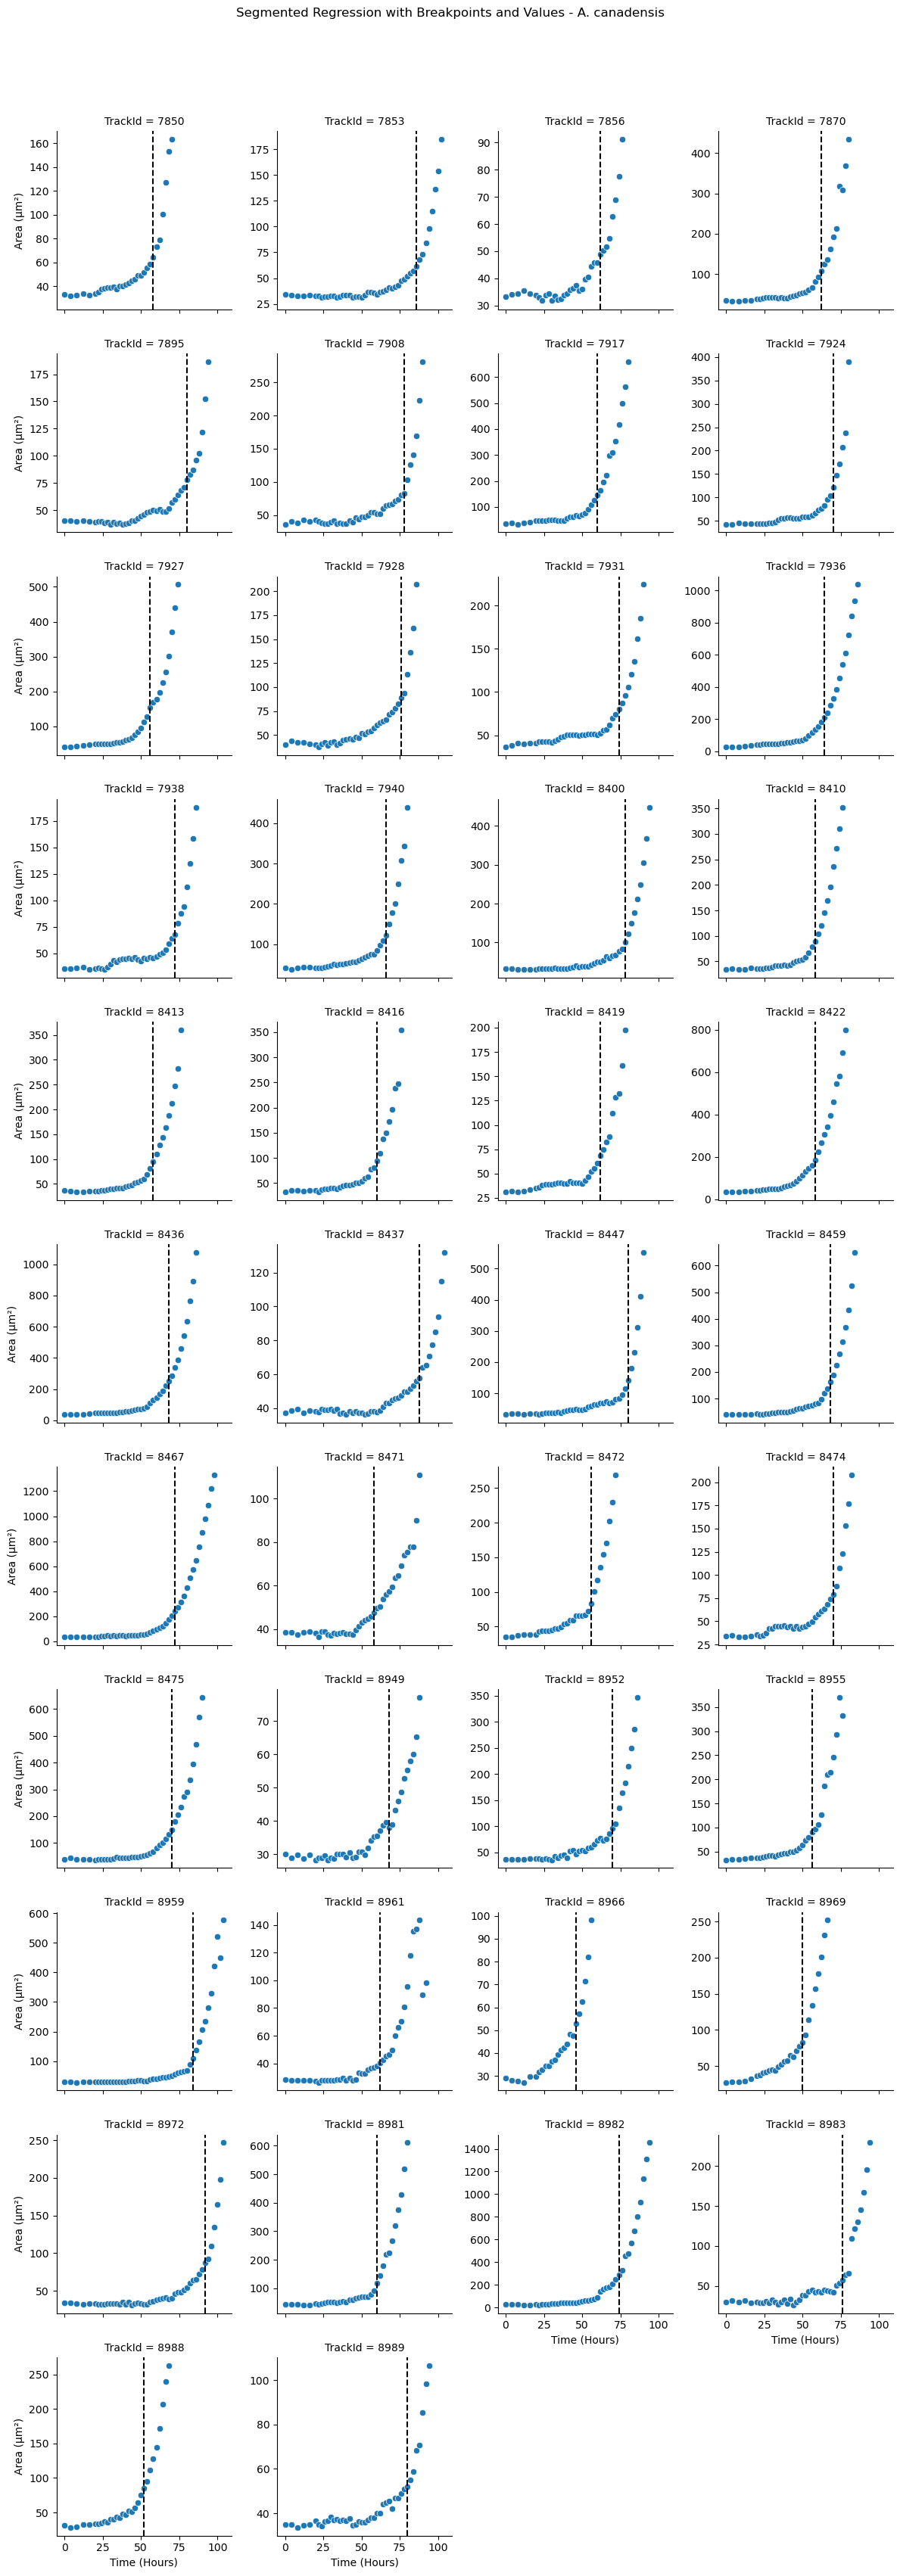

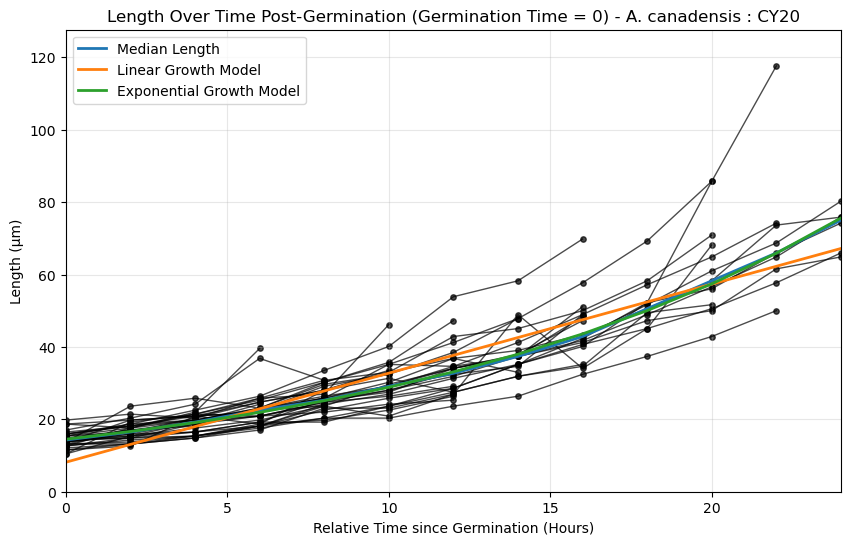

In [9]:
#A. canadensis CY20 19.08
#transform data to bind all sheet data with a new column called sheet_name to define data origin
a_canadensis_a_cy20_19_08_origional_time_column = germ_function.combine_excel_sheets(G1_As_canadensis_CY20)
a_canadensis_a_cy20_19_08_df = germ_function.rename_repetition_columns(a_canadensis_a_cy20_19_08_origional_time_column)

a_canadensis_b_cy20_19_08_origional_time_column = germ_function.combine_excel_sheets(G2_As_canadensis_CY20)
a_canadensis_b_cy20_19_08_df = germ_function.rename_repetition_columns(a_canadensis_b_cy20_19_08_origional_time_column)

a_canadensis_c_cy20_19_08_origional_time_column = germ_function.combine_excel_sheets(G3_As_canadensis_CY20)
a_canadensis_c_cy20_19_08_df = germ_function.rename_repetition_columns(a_canadensis_c_cy20_19_08_origional_time_column)



#for isotropic growth value use all replicate data combined
a_canadensis_cy20_19_08_total_df = pd.concat([a_canadensis_a_cy20_19_08_df, 
                                              a_canadensis_b_cy20_19_08_df, 
                                              a_canadensis_c_cy20_19_08_df])

a_canadensis_cy20_19_08_isotropic = germ_function.isotropic_growth(a_canadensis_cy20_19_08_total_df, 
                                                                  "A. canadensis", 
                                                                  "CY20", 
                                                                  "19.08.24")
#save isotropic data frame
a_canadensis_cy20_19_08_isotropic_df = a_canadensis_cy20_19_08_isotropic["isotropic_data"]

#Replicate A (Add replicate column for sorting later one)
a_canadensis_a_cy20_19_08_germiantion_data = germ_function.find_time_point(a_canadensis_a_cy20_19_08_df,
                                                               a_canadensis_cy20_19_08_isotropic_df.Average_Swelling_change.iloc[0], 
                                                               "A. canadensis", 
                                                               "CY20", 
                                                               "19.08.24")
a_canadensis_a_cy20_19_08_germiantion_data["Replicate"] = "A"

#Replicate B (Add replicate column for sorting later one)
a_canadensis_b_cy20_19_08_germiantion_data = germ_function.find_time_point(a_canadensis_b_cy20_19_08_df,
                                                               a_canadensis_cy20_19_08_isotropic_df.Average_Swelling_change.iloc[0], 
                                                               "A. canadensis", 
                                                               "CY20", 
                                                               "19.08.24")
a_canadensis_b_cy20_19_08_germiantion_data["Replicate"] = "B"

#Replicate C (Add replicate column for sorting later one)
a_canadensis_c_cy20_19_08_germiantion_data = germ_function.find_time_point(a_canadensis_c_cy20_19_08_df,
                                                               a_canadensis_cy20_19_08_isotropic_df.Average_Swelling_change.iloc[0], 
                                                               "A. canadensis", 
                                                               "CY20", 
                                                               "19.08.24")
a_canadensis_c_cy20_19_08_germiantion_data["Replicate"] = "C"

#combine all replicate data
a_canadensis_total_cy20_19_08_germiantion_data = pd.concat([a_canadensis_a_cy20_19_08_germiantion_data, 
                                                            a_canadensis_b_cy20_19_08_germiantion_data, 
                                                            a_canadensis_c_cy20_19_08_germiantion_data])
#median germiantion metrics of all replicates
a_canadensis_replicate_cy20_19_08_germiantion_data = (
    a_canadensis_total_cy20_19_08_germiantion_data.groupby(["Species", "Media", "Date", "Replicate", "ScanArea"])
    .agg(Germination_Time =  ("selected_time_point", "median"),
         SD_Germination_Time =  ("selected_time_point", "std"), 
         Linear_Growth =  ("linear_growth_rate", "median"),
         SD_Linear_Growth =  ("linear_growth_rate", "std"), 
         Exponential_Growth =  ("exponential_growth_rate", "median"),
         SD_Exponential_Growth =  ("exponential_growth_rate", "std"),
         n = ("TrackId", "size")).reset_index())

#average of all repicates
a_canadensis_total_replicate_cy20_19_08_germiantion_data = (
    a_canadensis_replicate_cy20_19_08_germiantion_data.groupby(["Species", "Media", "Date"])
    .agg(Germination_Time =  ("Germination_Time", "mean"),
         SD_Germination_Time =  ("Germination_Time", "std"), 
         Linear_Growth =  ("Linear_Growth", "mean"),
         SD_Linear_Growth =  ("Linear_Growth", "std"), 
         Exponential_Growth =  ("Exponential_Growth", "mean"),
         SD_Exponential_Growth =  ("Exponential_Growth", "std"),
         n = ("n", "sum")).reset_index())

#make sure all column names match
a_canadensis_total_replicate_cy20_19_08_germiantion_data["Replicate"] = "Replicate Total"
a_canadensis_total_replicate_cy20_19_08_germiantion_data["ScanArea"] = "Replicate Total"

#combine total data frames for analysis later
a_canadensis_replicate_cy20_19_08_germiantion_data = pd.concat([a_canadensis_replicate_cy20_19_08_germiantion_data, 
                                                                a_canadensis_total_replicate_cy20_19_08_germiantion_data])

a_canadensis_cy20_19_08_length_since_germination = germ_function.length_post_germination(a_canadensis_cy20_19_08_total_df, 
                                                                                        a_canadensis_total_cy20_19_08_germiantion_data,
                                                                                        "A. canadensis",
                                                                                        "CY20", 
                                                                                        "19.08.24")
print(a_canadensis_replicate_cy20_19_08_germiantion_data)

         Species Media      Date        Replicate            ScanArea  \
0  A. canadensis  MY70  19.08.24                A  G7_As canadensis_3   
1  A. canadensis  MY70  19.08.24                B  G8_As canadensis_3   
2  A. canadensis  MY70  19.08.24                C  G9_As canadensis_3   
0  A. canadensis  MY70  19.08.24  Replicate Total     Replicate Total   

   Germination_Time  SD_Germination_Time  Linear_Growth  SD_Linear_Growth  \
0              80.0            10.430724       1.676352          0.917500   
1              76.0            10.456258       1.670245          1.832252   
2              66.0             8.869423       1.196240          0.563717   
0              74.0             7.211103       1.514279          0.275447   

   Exponential_Growth  SD_Exponential_Growth   n  
0            0.043489               0.013006  11  
1            0.072605               0.014408   6  
2            0.043018               0.016256  24  
0            0.053037               0.016948

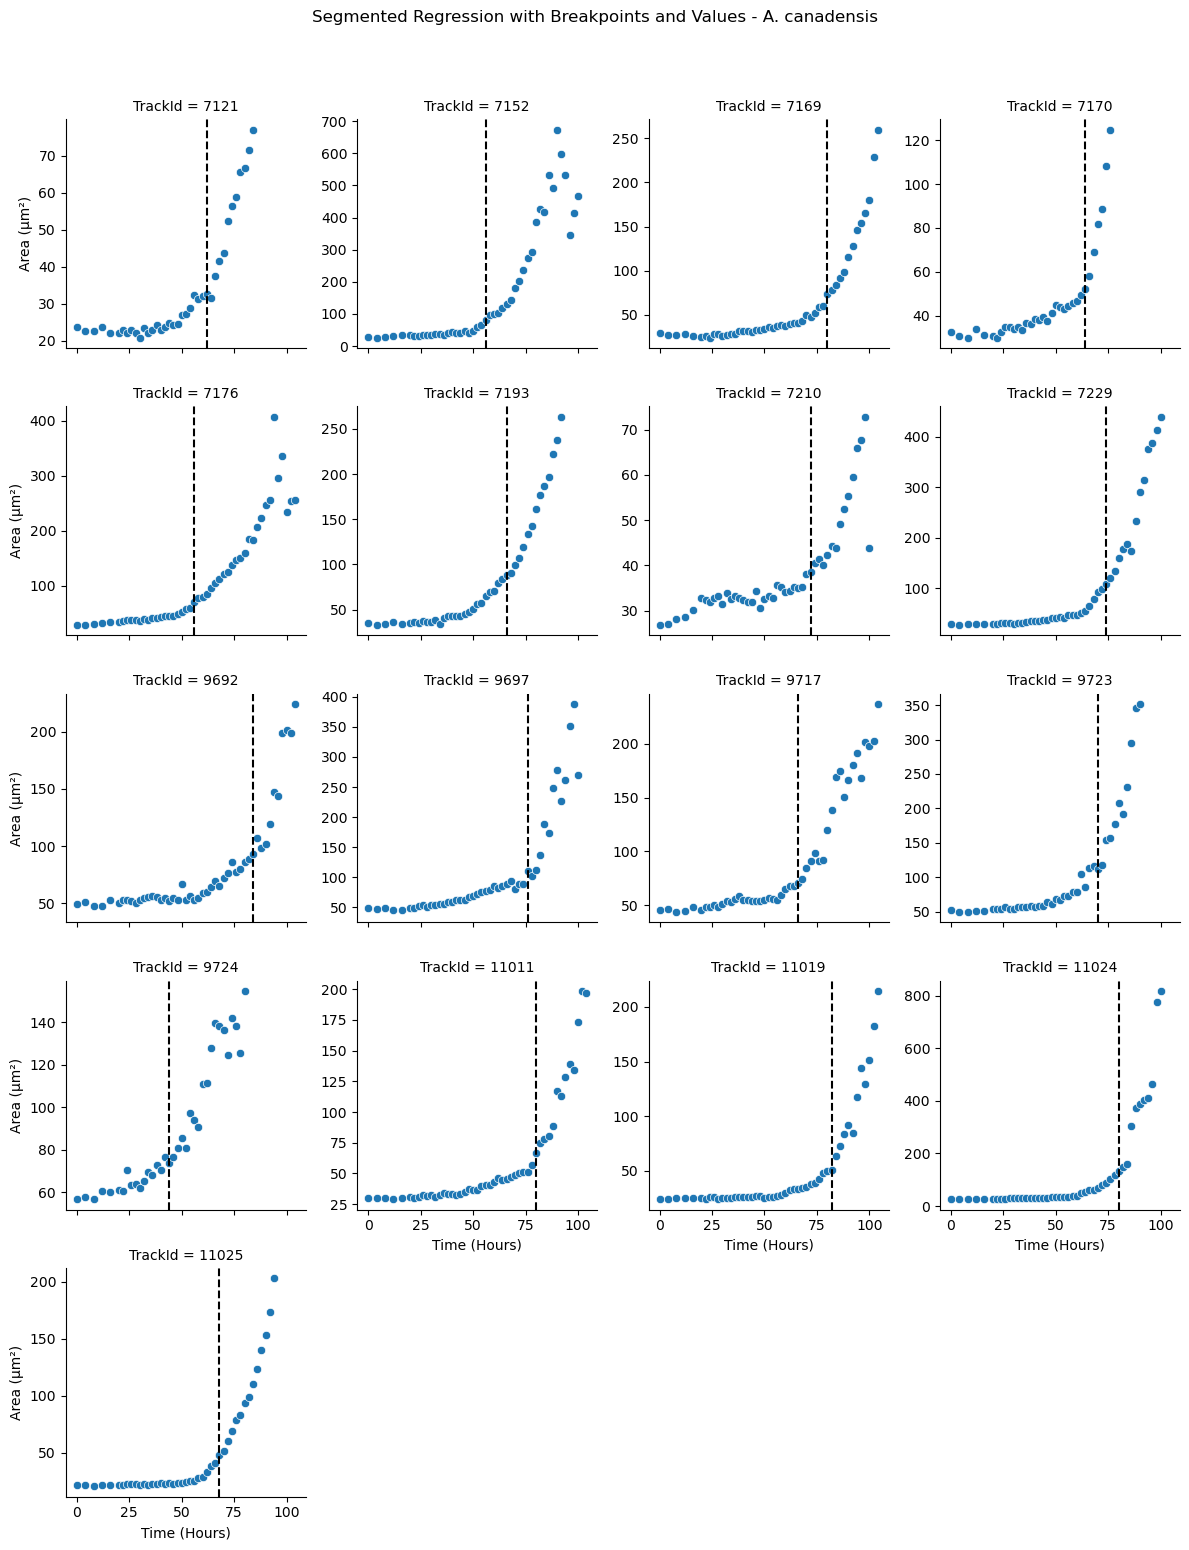

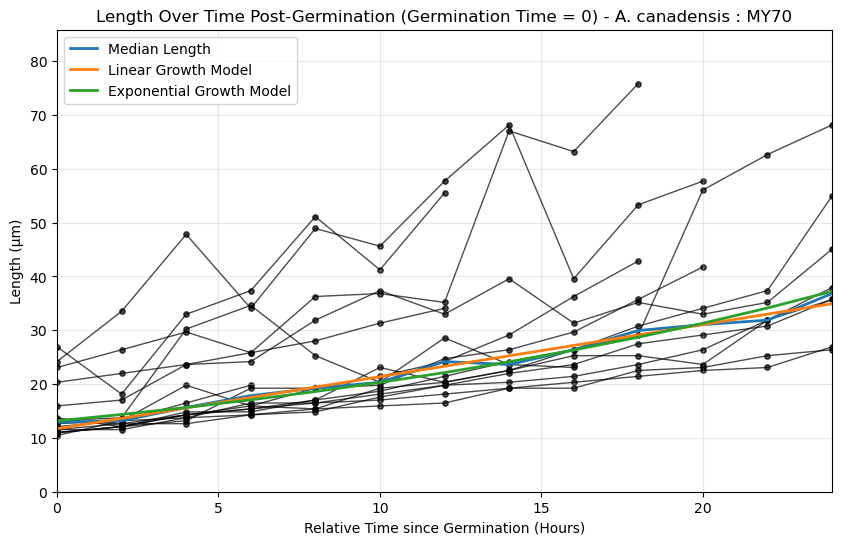

In [10]:
#A. canadensis MY70 19.08
#transform data to bind all sheet data with a new column called sheet_name to define data origin
a_canadensis_a_my70_19_08_origional_time_column = germ_function.combine_excel_sheets(G7_As_canadensis_MY70)
a_canadensis_a_my70_19_08_df = germ_function.rename_repetition_columns(a_canadensis_a_my70_19_08_origional_time_column)

a_canadensis_b_my70_19_08_origional_time_column = germ_function.combine_excel_sheets(G8_As_canadensis_MY70)
a_canadensis_b_my70_19_08_df = germ_function.rename_repetition_columns(a_canadensis_b_my70_19_08_origional_time_column)

a_canadensis_c_my70_19_08_origional_time_column = germ_function.combine_excel_sheets(G9_As_canadensis_MY70)
a_canadensis_c_my70_19_08_df = germ_function.rename_repetition_columns(a_canadensis_c_my70_19_08_origional_time_column)



#for isotropic growth value use all replicate data combined
a_canadensis_my70_19_08_total_df = pd.concat([a_canadensis_a_my70_19_08_df, 
                                              a_canadensis_b_my70_19_08_df, 
                                              a_canadensis_c_my70_19_08_df])

a_canadensis_my70_19_08_isotropic = germ_function.isotropic_growth(a_canadensis_my70_19_08_total_df, 
                                                                  "A. canadensis", 
                                                                  "MY70", 
                                                                  "19.08.24")
#save isotropic data frame
a_canadensis_my70_19_08_isotropic_df = a_canadensis_my70_19_08_isotropic["isotropic_data"]

#Replicate A (Add replicate column for sorting later one)
a_canadensis_a_my70_19_08_germiantion_data = germ_function.find_time_point(a_canadensis_a_my70_19_08_df,
                                                               a_canadensis_my70_19_08_isotropic_df.Average_Swelling_change.iloc[0], 
                                                               "A. canadensis", 
                                                               "MY70", 
                                                               "19.08.24")
a_canadensis_a_my70_19_08_germiantion_data["Replicate"] = "A"

#Replicate B (Add replicate column for sorting later one)
a_canadensis_b_my70_19_08_germiantion_data = germ_function.find_time_point(a_canadensis_b_my70_19_08_df,
                                                               a_canadensis_my70_19_08_isotropic_df.Average_Swelling_change.iloc[0], 
                                                               "A. canadensis", 
                                                               "MY70", 
                                                               "19.08.24")
a_canadensis_b_my70_19_08_germiantion_data["Replicate"] = "B"

#Replicate C (Add replicate column for sorting later one)
a_canadensis_c_my70_19_08_germiantion_data = germ_function.find_time_point(a_canadensis_c_my70_19_08_df,
                                                               a_canadensis_my70_19_08_isotropic_df.Average_Swelling_change.iloc[0], 
                                                               "A. canadensis", 
                                                               "MY70", 
                                                               "19.08.24")
a_canadensis_c_my70_19_08_germiantion_data["Replicate"] = "C"

#combine all replicate data
a_canadensis_total_my70_19_08_germiantion_data = pd.concat([a_canadensis_a_my70_19_08_germiantion_data, 
                                                            a_canadensis_b_my70_19_08_germiantion_data, 
                                                            a_canadensis_c_my70_19_08_germiantion_data])
#median germiantion metrics of all replicates
a_canadensis_replicate_my70_19_08_germiantion_data = (
    a_canadensis_total_my70_19_08_germiantion_data.groupby(["Species", "Media", "Date", "Replicate", "ScanArea"])
    .agg(Germination_Time =  ("selected_time_point", "median"),
         SD_Germination_Time =  ("selected_time_point", "std"), 
         Linear_Growth =  ("linear_growth_rate", "median"),
         SD_Linear_Growth =  ("linear_growth_rate", "std"), 
         Exponential_Growth =  ("exponential_growth_rate", "median"),
         SD_Exponential_Growth =  ("exponential_growth_rate", "std"),
         n = ("TrackId", "size")).reset_index())

#average of all repicates
a_canadensis_total_replicate_my70_19_08_germiantion_data = (
    a_canadensis_replicate_my70_19_08_germiantion_data.groupby(["Species", "Media", "Date"])
    .agg(Germination_Time =  ("Germination_Time", "mean"),
         SD_Germination_Time =  ("Germination_Time", "std"), 
         Linear_Growth =  ("Linear_Growth", "mean"),
         SD_Linear_Growth =  ("Linear_Growth", "std"), 
         Exponential_Growth =  ("Exponential_Growth", "mean"),
         SD_Exponential_Growth =  ("Exponential_Growth", "std"),
         n = ("n", "sum")).reset_index())

#make sure all column names match
a_canadensis_total_replicate_my70_19_08_germiantion_data["Replicate"] = "Replicate Total"
a_canadensis_total_replicate_my70_19_08_germiantion_data["ScanArea"] = "Replicate Total"

#combine total data frames for analysis later
a_canadensis_replicate_my70_19_08_germiantion_data = pd.concat([a_canadensis_replicate_my70_19_08_germiantion_data, 
                                                                a_canadensis_total_replicate_my70_19_08_germiantion_data])

a_canadensis_my70_19_08_length_since_germination = germ_function.length_post_germination(a_canadensis_my70_19_08_total_df, 
                                                                                        a_canadensis_total_my70_19_08_germiantion_data,
                                                                                        "A. canadensis",
                                                                                        "MY70", 
                                                                                        "19.08.24")
print(a_canadensis_replicate_my70_19_08_germiantion_data)